In [8]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cf
import datetime

In [9]:
def get_linregress_slope(arr):
    if (np.isnan(arr)).any():
        result = np.nan
    else:
        result = np.polyfit([i for i in range(len(arr))],arr,deg=1)[0]
        
    return(result)


def fire_season(month):
    return (month >= 5) & (month <= 10)    
    

In [10]:
# create vege masks 
vege_ds = xr.open_dataset('/nesi/project/niwa00015/queenle/data/ERA5/monthly/vegetation/1951-2021.nc')
vege_ds['longitude'] = [lon + 360 for lon in vege_ds.longitude.data]
era5_combined = (vege_ds.lai_hv + vege_ds.lai_lv).max('time')
era5_vege_mask = era5_combined.where(era5_combined>3.5)

box = [(32,55),(232,256)]


In [16]:
# load input variable datasets
print('loading datasets')
era5_ideal = xr.open_dataset('/nesi/project/niwa00015/queenle/data/fire/ERA5/ideal-style/ERA5_FWI_inputs.nc')
era5_ideal['fwi'] = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/ERA5/ideal-style/ERA5_FWI.nc')
era5_ideal['longitude'] = [lon + 360 for lon in era5_ideal.longitude.data]
era5_ideal = era5_ideal.sel(latitude=slice(box[0][1],box[0][0]),longitude=slice(box[1][0],box[1][1]))


era5_model = xr.open_dataset('/nesi/project/niwa00015/queenle/data/fire/ERA5/model-style/daily/inputs_1951-2021.nc')
era5_model['fwi'] = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/ERA5/model-style/daily/ERA5_FWI_1951-2021.nc')
era5_model['longitude'] = [lon + 360 for lon in era5_model.longitude.data]
era5_model = era5_model.sel(latitude=slice(era5_ideal.latitude[0],era5_ideal.latitude[-1]),longitude=slice(era5_ideal.longitude[0],era5_ideal.longitude[-1]))

# mask data
era5_ideal = era5_ideal.where(era5_vege_mask>0)
era5_model = era5_model.where(era5_vege_mask>0)

loading datasets


In [17]:
# calc fire-season means

era5_ideal_FS = era5_ideal.sel(time=fire_season(era5_ideal['time.month'])).resample(time ='A').mean('time')
era5_model_FS = era5_model.sel(time=fire_season(era5_model['time.month'])).resample(time ='A').mean('time')

era5_model_FS = era5_model_FS.sel(time=slice('1979','2021'))

In [18]:
var_dict = {'FWI':['fwi','fwi'],'TEMP':['mx2t','t2m'],'PRECIP':['tp','tp'],'Rel.HUM':['min_rh','rh'],'WIND':['wind','wind']}

cb_ranges = {'FWI':[0,60],'TEMP':[0,30],'PRECIP':[0,10],'Rel.HUM':[20,70],'WIND':[0,30]}
cb_ticks = {'FWI':[[0,30,60],['0','30','60']],'TEMP':[[0,15,30],['0','15','30']],'PRECIP':[[0,5,10],['0','5','10']],
            'Rel.HUM':[[20,45,70],['20','45','70']],'WIND':[[0,15,30],['0','15','30']]}
labels = {'FWI':'FWI','TEMP':'C','PRECIP':'mm/hr','Rel.HUM':'%','WIND':'km/hr'}

In [19]:
font = {'family': 'sans-serif',
        'color':  'black',
        'weight': 'normal',
        'size': 20,
        }

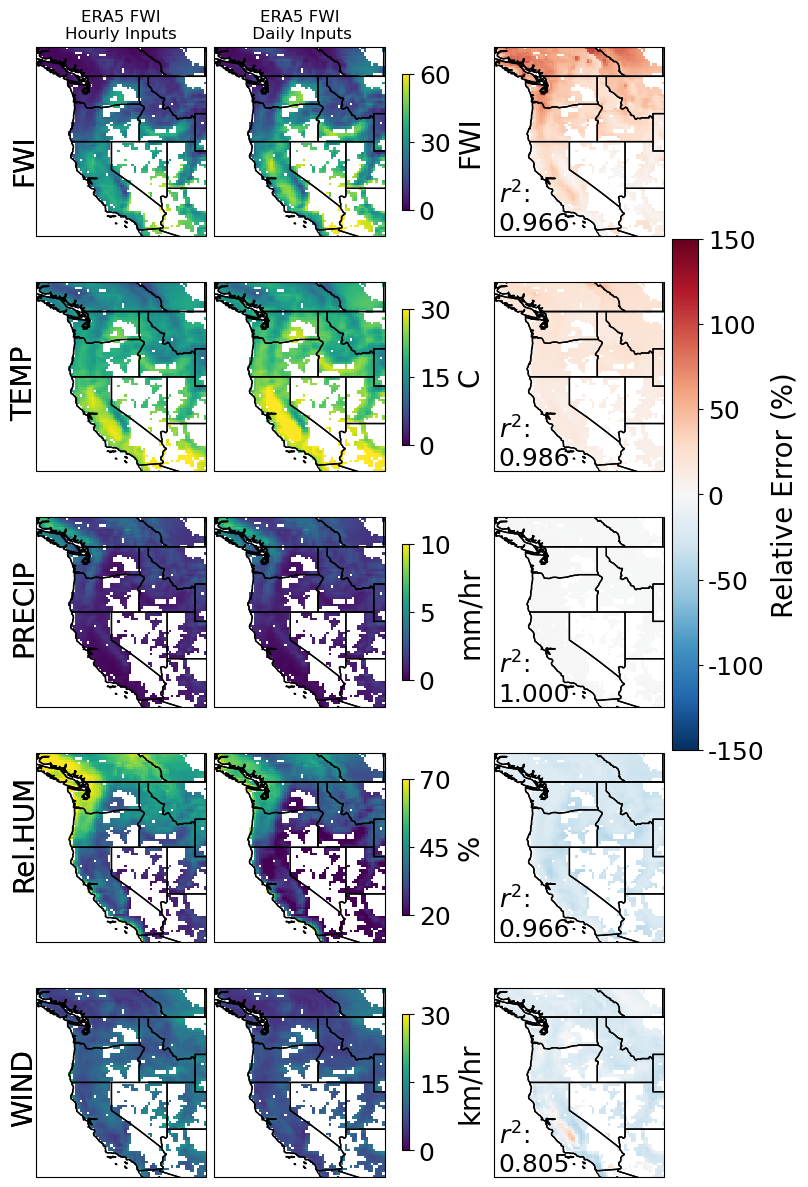

In [21]:
fig,axs = plt.subplots(5,3,figsize=(8,12),layout='constrained',sharex=True,sharey=True,subplot_kw=dict(projection=ccrs.PlateCarree()))

for i,var in enumerate(['FWI','TEMP','PRECIP','Rel.HUM','WIND']):
    
    model = era5_model_FS[var_dict[var][0]].mean('time')
    ideal = era5_ideal_FS[var_dict[var][1]].mean('time')
    error = ((model - ideal)/ideal)*100
    
    corr = xr.corr(model,ideal).data**2
    
    ideal_im = ideal.plot(ax=axs[i][0],vmin=cb_ranges[var][0],vmax=cb_ranges[var][1],transform=ccrs.PlateCarree(),add_colorbar=False)
    model_im = model.plot(ax=axs[i][1],vmin=cb_ranges[var][0],vmax=cb_ranges[var][1],transform=ccrs.PlateCarree(),add_colorbar=False)
    error_im = error.plot(ax=axs[i][2],vmin=-150,vmax=150,cmap='RdBu_r',transform=ccrs.PlateCarree(),add_colorbar=False)
    
    axs[i][2].text(0.03, 0.03, r'$r^2$' + f':\n{corr:.3f}', size=18, color='black', transform=axs[i][2].transAxes)
    
    axs[i][0].text(-0.15,0.3,var,fontdict=font,transform=axs[i][0].transAxes, rotation='vertical',ma='center')

    # mean color bars
    cb = fig.colorbar(model_im, ax=axs[i, 0:2], shrink=0.6,orientation='vertical')
    cb.set_label(labels[var],fontdict=font)
    font['size']=18
    cb.set_ticks(cb_ticks[var][0],labels=cb_ticks[var][1],fontdict=font)
    font['size']=20
    axs[i][0].text(-0.15,0.3,var,fontdict=font,transform=axs[i][0].transAxes, rotation='vertical',ma='center')

cb = fig.colorbar(error_im, ax=axs[0:4, 2], shrink=0.6,orientation='vertical')
cb.set_label('Relative Error (%)',fontdict=font)
font['size']=18
cb.set_ticks([-150+50*i for i in range(7)],labels=[str(-150+50*i) for i in range(7)],fontdict=font)
font['size']=20

for ax in axs.flatten():
    ax.set_title('')
    ax.coastlines()
    ax.add_feature(cf.BORDERS)
    ax.add_feature(cf.STATES)
    
axs[0][0].set_title('ERA5 FWI\nHourly Inputs')
axs[0][1].set_title('ERA5 FWI\n Daily Inputs')

plt.savefig(f'/home/queenle/fire_attribution/figures/sup_mat/SM_Fig1_hourly_daily.png',dpi=300)

Text(0.5, 1.0, 'ERA5 FWI\n Daily Inputs')

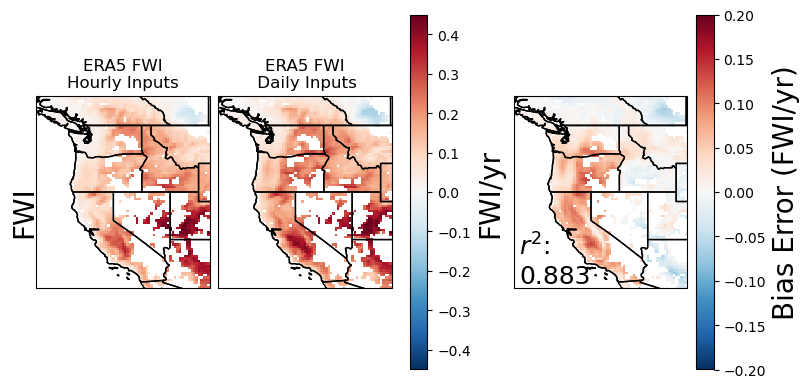

In [112]:
fig,axs = plt.subplots(1,3,figsize=(8,6),layout='constrained',sharex=True,sharey=True,subplot_kw=dict(projection=ccrs.PlateCarree()))

var = 'FWI'

model = xr.apply_ufunc(get_linregress_slope, era5_model_FS[var_dict[var][0]], input_core_dims=[["time"]], vectorize = True)
ideal = xr.apply_ufunc(get_linregress_slope, era5_ideal_FS[var_dict[var][1]], input_core_dims=[["time"]], vectorize = True)
error = model - ideal

corr = xr.corr(model,ideal).data**2

ideal_im = ideal.plot(ax=axs[0],vmin=-0.45,vmax=0.45,cmap='RdBu_r',transform=ccrs.PlateCarree(),add_colorbar=False)
model_im = model.plot(ax=axs[1],vmin=-0.45,vmax=0.45,cmap='RdBu_r',transform=ccrs.PlateCarree(),add_colorbar=False)
error_im = error.plot(ax=axs[2],vmin=-0.2,vmax=0.2,cmap='RdBu_r',transform=ccrs.PlateCarree(),add_colorbar=False)

axs[2].text(0.03, 0.03, r'$r^2$' + f':\n{corr:.3f}', size=18, color='black', transform=axs[2].transAxes)

# mean color bars
cb = fig.colorbar(model_im, ax=axs[0:2], shrink=0.6,orientation='vertical')
cb.set_label('FWI/yr',fontdict=font)
font['size']=18
#cb.set_ticks(cb_ticks[var][0],labels=cb_ticks[var][1],fontdict=font)
font['size']=20

cb = fig.colorbar(error_im, ax=axs[2], shrink=0.6,orientation='vertical')
cb.set_label('Bias Error (FWI/yr)',fontdict=font)
font['size']=18
#cb.set_ticks([-150+50*i for i in range(7)],labels=[str(-150+50*i) for i in range(7)],fontdict=font)
font['size']=20

for ax in axs.flatten():
    ax.set_title('')
    ax.coastlines()
    ax.add_feature(cf.BORDERS)
    ax.add_feature(cf.STATES)
    
axs[0].set_title('ERA5 FWI\nHourly Inputs')
axs[1].set_title('ERA5 FWI\n Daily Inputs')



In [113]:
var_dict = {'FWI':['fwi','fwi'],'TEMP':['mx2t','t2m'],'PRECIP':['tp','tp'],'Rel.HUM':['min_rh','rh'],'WIND':['wind','wind']}

cb_ranges = {'FWI':[-0.45,0.45],'TEMP':[-0.06,0.06],'PRECIP':[-0.02,0.02],'Rel.HUM':[-0.3,0.3],'WIND':[-0.04,0.04]}
cb_ticks = {'FWI':[[0,30,60],['0','30','60']],'TEMP':[[0,15,30],['0','15','30']],'PRECIP':[[0,5,10],['0','5','10']],
            'Rel.HUM':[[20,45,70],['20','45','70']],'WIND':[[0,15,30],['0','15','30']]}
labels = {'FWI':'FWI/yr','TEMP':'C/yr','PRECIP':'mm/hr/yr','Rel.HUM':'%/yr','WIND':'km/hr/yr'}

Text(0.5, 1.0, 'ERA5 FWI\n Daily Inputs')

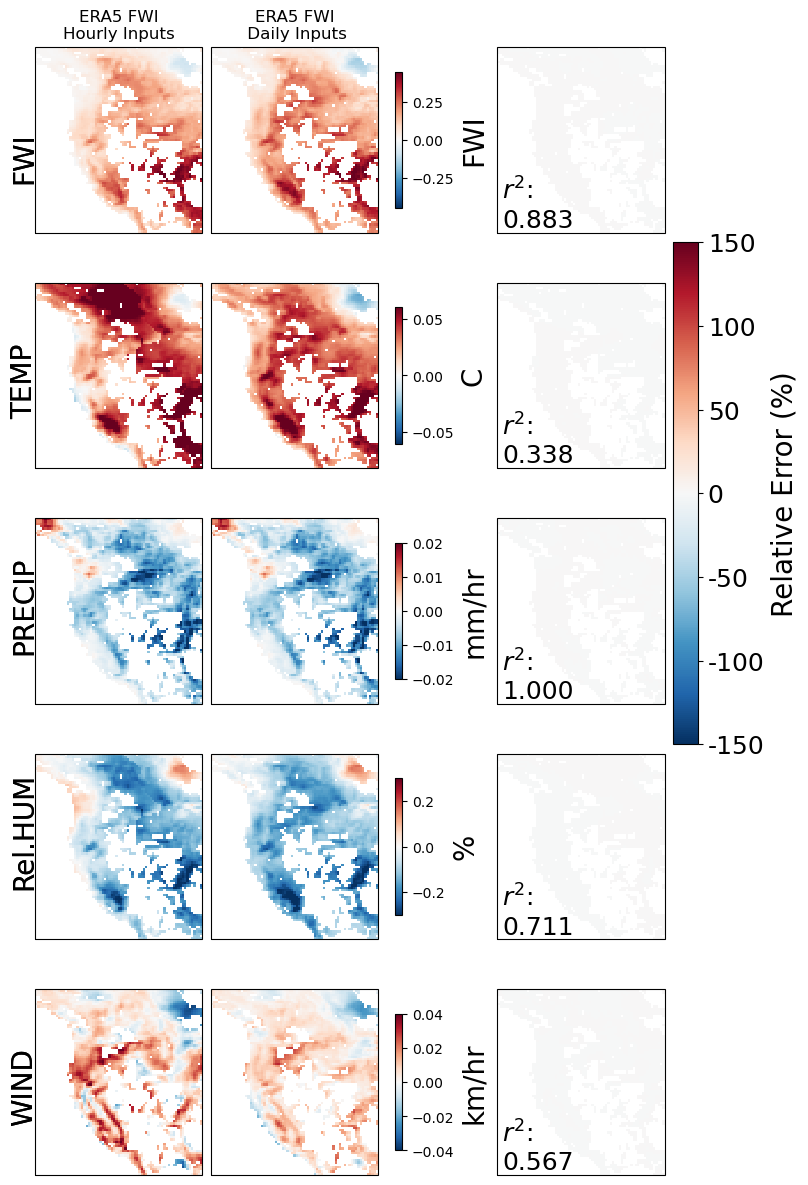

In [115]:
fig,axs = plt.subplots(5,3,figsize=(8,12),layout='constrained',sharex=True,sharey=True,subplot_kw=dict(projection=ccrs.PlateCarree()))

for i,var in enumerate(['FWI','TEMP','PRECIP','Rel.HUM','WIND']):
    
    model = xr.apply_ufunc(get_linregress_slope, era5_model_FS[var_dict[var][0]], input_core_dims=[["time"]], vectorize = True)
    ideal = xr.apply_ufunc(get_linregress_slope, era5_ideal_FS[var_dict[var][1]], input_core_dims=[["time"]], vectorize = True)
    error = model - ideal
        
    corr = xr.corr(model,ideal).data**2
    
    ideal_im = ideal.plot(ax=axs[i][0],vmin=cb_ranges[var][0],vmax=cb_ranges[var][1],cmap='RdBu_r',transform=ccrs.PlateCarree(),add_colorbar=False)
    model_im = model.plot(ax=axs[i][1],vmin=cb_ranges[var][0],vmax=cb_ranges[var][1],cmap='RdBu_r',transform=ccrs.PlateCarree(),add_colorbar=False)
    error_im = error.plot(ax=axs[i][2],vmin=-150,vmax=150,cmap='RdBu_r',transform=ccrs.PlateCarree(),add_colorbar=False)
    
    axs[i][2].text(0.03, 0.03, r'$r^2$' + f':\n{corr:.3f}', size=18, color='black', transform=axs[i][2].transAxes)
    
    axs[i][0].text(-0.15,0.3,var,fontdict=font,transform=axs[i][0].transAxes, rotation='vertical',ma='center')

    # mean color bars
    cb = fig.colorbar(model_im, ax=axs[i, 0:2], shrink=0.6,orientation='vertical')
    cb.set_label(labels[var],fontdict=font)
    font['size']=18
    #cb.set_ticks(cb_ticks[var][0],labels=cb_ticks[var][1],fontdict=font)
    font['size']=20
    axs[i][0].text(-0.15,0.3,var,fontdict=font,transform=axs[i][0].transAxes, rotation='vertical',ma='center')

cb = fig.colorbar(error_im, ax=axs[0:4, 2], shrink=0.6,orientation='vertical')
cb.set_label('Relative Error (%)',fontdict=font)
font['size']=18
cb.set_ticks([-150+50*i for i in range(7)],labels=[str(-150+50*i) for i in range(7)],fontdict=font)
font['size']=20

for ax in axs.flatten():
    ax.set_title('')
    
axs[0][0].set_title('ERA5 FWI\nHourly Inputs')
axs[0][1].set_title('ERA5 FWI\n Daily Inputs')


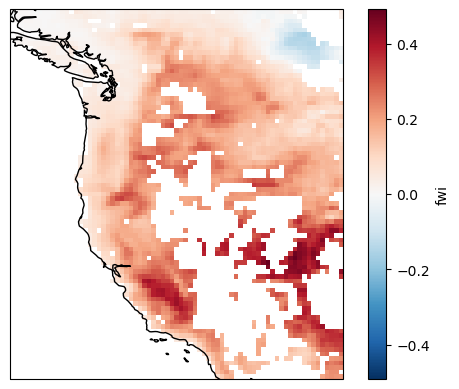

In [94]:
fig,axs = plt.subplots(subplot_kw=dict(projection=ccrs.PlateCarree()))

xr.apply_ufunc(get_linregress_slope, era5_model_FS['fwi'], input_core_dims=[["time"]], vectorize = True).plot(ax=axs)

axs.coastlines()